<a href="https://colab.research.google.com/github/mrJoao28/Car-pricing-prediction-/blob/main/CarPricePredication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
from tensorflow.keras.layers import Normalization,Dense,InputLayer
from tensorflow.keras.losses import  MeanAbsoluteError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

data preparation

In [5]:
data = pd.read_csv("train.csv",sep=",")

In [58]:
tensor_data = tf.constant(data)
tensor_data = tf.cast(tensor_data,dtype=tf.float64)
tensor_data = tf.random.shuffle(tensor_data,100);

In [32]:
x =tensor_data[:,3:-1]
y = tensor_data[:,-1]
y = tf.expand_dims(y , axis= -1)

In [33]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
DATASET_SIZE = len(x)

In [34]:
x_train = x[:int(DATASET_SIZE*TRAIN_RATIO)]
y_train = y[:int(DATASET_SIZE*TRAIN_RATIO)]


In [40]:
x_val = x[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO))]
y_val = y[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO))]

In [81]:
x_test = x[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO))]
y_test = y[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO))]

In [75]:
normalizer = Normalization()
normalizer.adapt(x_train)

In [76]:
model = tf.keras.Sequential([
    InputLayer(input_shape=(8,)),
    normalizer,
    Dense(128, activation='relu'),
    Dense(256,activation='relu'),
    Dense(256,activation='relu'),
    Dense(256,activation='relu'),
    Dense(256,activation='relu'),
    Dense(128, activation='relu'),
    Dense(256,activation='relu'),
    Dense(256,activation='relu'),
    Dense(256,activation='relu'),
    Dense(256,activation='relu'),
    Dense(128, activation='relu'),
    Dense(128,activation='relu'),
    Dense(128,activation='relu'),
    Dense(32,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


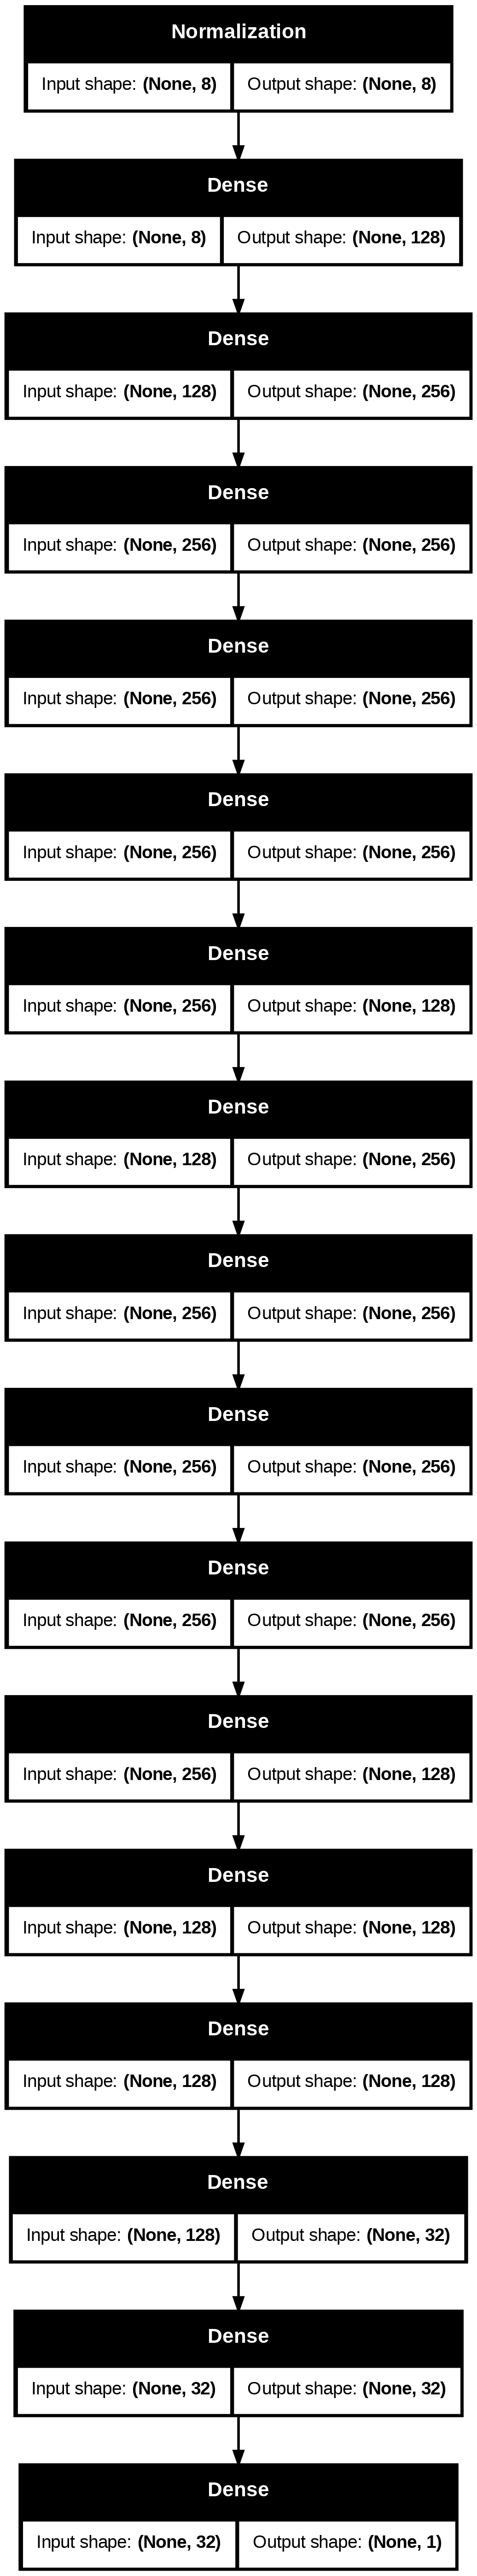

In [77]:
tf.keras.utils.plot_model(model, to_file = "model.png",
                          show_shapes=True)

In [85]:
model.compile(optimizer=Adam(learning_rate=0.000001),loss = MeanAbsoluteError)

In [90]:
history = model.fit(x=x_train,y=y_train,validation_data=(x_val,y_val),epochs=600 , verbose=1)

Epoch 1/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10847.3701 - val_loss: 43792.5391
Epoch 2/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10982.3477 - val_loss: 43799.5938
Epoch 3/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10901.5664 - val_loss: 43817.1992
Epoch 4/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10917.0381 - val_loss: 43776.1797
Epoch 5/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10683.4102 - val_loss: 43840.8945
Epoch 6/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11016.2734 - val_loss: 43793.0664
Epoch 7/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11199.0098 - val_loss: 43778.9102
Epoch 8/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10795.5645 - val_loss: 43823.0391
Epoch 9/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10638.3584 - val_loss: 43843.4414
Epoch 10/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10531.8281 - val_loss: 43777.5039
Epoch 11/600
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10845.550

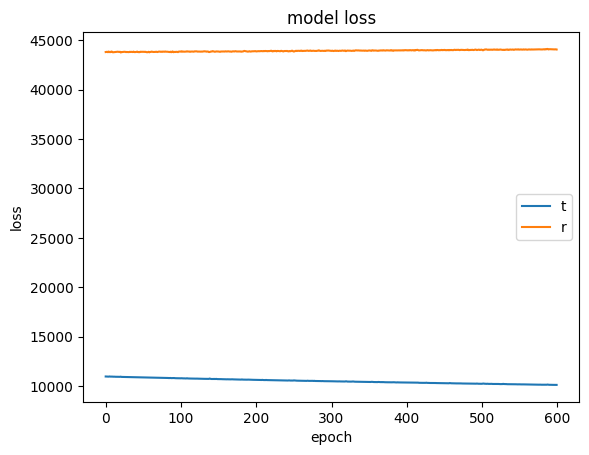

In [91]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model loss")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend('train')
plt.show()

In [92]:
model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 45423.5703


44048.63671875

In [93]:

model.predict(tf.expand_dims(x_test[0],axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[196959.1]], dtype=float32)

In [94]:
y_test[0]

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([199798.])>